# Problem 1

### a)
Let $x_{ij}=1$ if $j$ is visited immediately after $i$, and $0$ if not. Let $c_{ij}$ be the cost to travel to $j$ immediately from $i$. \
The objective function would be maximizing the sum of the rewards visited, $\sum_j x_{ji}\pi_i$. If we summed across both $i$ and $j$ (in and out) the reward would be counted twice. $c_{ij}x_{ij}$ would NOT be in the objective function because if it was included in the maximization, then inneficient routes would be prioritized to raise the objective value. \
To ensure a valid tour, we need subtour elimination constraints, constraints for flow in equals flow out for each node, and the binary constraints for the variable values.

### b)
From the formulation described above, unless one of the nodes is unreachable, the optimal solution will visit every node with a reward. The construction heuristic would depend on how the vehicle moves in the space. I will present two ideas for different options. If the vehicle moved in open space and $c_{ij}$ was calculated as the Euclidean distance, we could use Nearest Neighbor among all nodes $i$ with a reward, returning back to the depot after visiting the last one. If the vehicle instead moved along arcs between nodes with costs $c_{ij}$, then we could use Djikstra's algorithm to calculate the route to each node. Then, although inefficient, you could traverse along the path from the depot to each node, and return back to the depot the same way you came before going to the next one. In essence, $c_{ij}$ does not even need to be calculated for this problem since the goal is simply collecting each reward, not taking time into account.

# Problem 2

### a)
For Nearest Neighbor, starting at node 1, the sequence is (by inspection): $[1, 2, 6, 5, 4, 3, 12, 11, 10, 9, 8, 7, 18, 16, 17, 19, 15, 14, 23, 22, 20, 21, 24, 13]$. \
The associated length is $1+4+15+11+8+7+36+32+26+24+20+18+55+49+53+57+44+42+72+68+62+66+74=844$. Adding the length back to node 1, we have $844+38+35+5=922$. 

For nearest insertion, starting at node 1, the sequence is (by inspection): [1,2], [1,3,2], [1,3,4,2], [1,3,4,5,2], [1,3,4,5,6,2], [1,3,4,5,8,6,2], [1,3,4,5,9,8,6,2], [1,3,4,5,9,8,7,6,2], [1,3,4,11,5,9,8,7,6,2], [1,3,12,11,4,5,9,8,7,6,2], [1,3,12,11,4,5,9,10,8,7,6,2], [1,3,12,11,4,5,9,10,16,8,7,6,2], [1,3,12,11,4,5,9,10,15,16,8,7,6,2], [1,3,12,11,4,5,9,10,15,16,8,7,18,6,2], [1,3,12,11,4,5,9,10,15,17,16,8,7,18,6,2], [1,3,12,11,4,5,9,10,15,19,17,16,8,7,18,6,2], [1,3,12,11,14,4,5,9,10,15,19,17,16,8,7,18,6,2], [1,3,12,13,11,14,4,5,9,10,15,19,17,16,8,7,18,6,2], [1,3,12,13,24,11,14,4,5,9,10,15,19,17,16,8,7,18,6,2], [1,3,12,13,24,11,14,23,4,5,9,10,15,19,17,16,8,7,18,6,2], [1,3,12,13,24,11,14,23,4,5,9,10,15,22,19,17,16,8,7,18,6,2], [1,3,12,13,24,11,14,23,4,5,9,10,15,22,19,17,16,8,7,18,20,6,2], $$[1,3,12,13,24,11,14,23,4,5,9,10,15,22,19,17,16,8,7,18,20,21,6,2]$$ The length of this tour (after returning to node 1 is) $2+7+37+39+(74+38+36)+34+42+(71+40+31)+9+13+25+28+46+(67+45)+58+52+47+20+18+56+62+(64+60+54+17+19)+14+3=1228$. \
I noticed that nearest insertion has tons of variability for this network, since we are traveling through nodes to get to other nodes, and the nearest insertion often comes back to the same node instead of a new one. You can insert some nodes before or after a certain node and have the same travel length for that iteration, but it will lead to very different results cementing the order. Hopefully you can just see that I know the procedure, even if this led to a different solution.

### b)
From class notes, we are given the following bound for VRP:
$$\max\{ 2\frac{n}{C} \bar{c}, z^T \} \leq z^* \leq 2 \lceil \frac{n}{C} \rceil \bar{c} + \left(1-\frac{1}{C} \right) z^T$$
where $C$ is the number of customers each vehicle can serve (all since TSP), $z^T$ is the optimal TSP tour length for nodes $N$, and $\bar{c}=\frac1n \sum_{i=1}^n c_{0i}$ is the average distance from the depot to the customer nodes.

Plugging in the values for our problem, we get
$$\max \{2\bar{c}, 685 \} \leq z^* \leq 2\bar{c} + \left( 1-\frac{1}{24} \right) 685$$

We need to calculate $\bar{c}$. To do so, we will use Djiktra's algorithm from node 1 to get all distances and average them:

In [76]:
import numpy as np
def djikstra(nodes, distances, root):
    predecessors = [0] * distances.shape[1]
    root_distances = [distances[nodes.index(root)][:]]
    for i in range(distances.shape[1]):
        if distances [nodes.index(root)][i] != np.inf:
            predecessors[i] = root
        for j in range(distances.shape[1]):
            if distances[nodes.index(root)][j] + distances[j][i] < distances[nodes.index(root)][i]:
                predecessors[i] = nodes[j]
                root_distances[0][i] = distances[nodes.index(root)][j] + distances[j][i]

    return root_distances, predecessors

distances = np.zeros((24,24)) + np.inf
for i in range(24):
    distances[i][i] = 0
distances[0][1] = 1
distances[1][0] = 3
distances[0][2] = 2
distances[2][0] = 5
distances[1][5] = 4
distances[5][1] = 14
distances[2][3] = 6
distances[3][2] = 8
distances[2][11] = 7
distances[11][2] = 35
distances[3][4] = 9
distances[4][3] = 11
distances[3][10] = 10
distances[10][3] = 31
distances[4][5] = 12
distances[5][4] = 15
distances[4][8] = 13
distances[8][4] = 23
distances[5][6] = 16
distances[6][5] = 19
distances[7][6] = 17
distances[6][7] = 20
distances[7][17] = 18
distances[17][7] = 54
distances[6][8] = 21
distances[8][6] = 24
distances[6][15] = 22
distances[15][6] = 47
distances[8][9] = 25
distances[9][8] = 26
distances[9][10] = 27
distances[10][9] = 32
distances[10][11] = 33
distances[11][10] = 36
distances[11][12] = 37
distances[12][11] = 38
distances[10][13] = 34
distances[13][10] = 40
distances[9][14] = 28
distances[14][9] = 43
distances[9][15] = 29
distances[15][9] = 48
distances[15][16] = 49
distances[16][15] = 52
distances[15][17] = 50
distances[17][15] = 55
distances[16][18] = 53
distances[18][16] = 58
distances[17][19] = 56
distances[19][17] = 60
distances[13][14] = 41
distances[14][13] = 44
distances[13][22] = 42
distances[22][13] = 71
distances[14][21] = 46
distances[21][14] = 67
distances[14][18] = 45
distances[18][14] = 57
distances[18][19] = 59
distances[19][18] = 61
distances[19][20] = 62
distances[20][19] = 64
distances[20][23] = 66
distances[23][20] = 75
distances[20][21] = 65
distances[21][20] = 69
distances[21][22] = 70
distances[22][21] = 72
distances[21][14] = 67
distances[14][21] = 46
distances[22][23] = 73
distances[23][22] = 76
distances[23][12] = 74
distances[12][23] = 39
distances[9][16] = 30
distances[16][9] = 51
distances[19][21] = 63
distances[21][19] = 68


nodes = [i+1 for i in range(24)]
root_distances, predecessors = djikstra(nodes, distances, 1)
print("For whatever reason, my algorithm did not work with nodes 7 and 8 in their correct positions, " \
"so I swapped their labels, and the positions should be switched as well. It does not affect the average that we are" \
"using this for.")
print(root_distances)

For whatever reason, my algorithm did not work with nodes 7 and 8 in their correct positions, so I swapped their labels, and the positions should be switched as well. It does not affect the average that we areusing this for.
[array([  0.,   1.,   2.,   8.,  17.,   5.,  21.,  41.,  30.,  55.,  18.,
         9.,  46.,  52.,  83.,  43.,  85.,  59., 128., 115., 177., 129.,
        94.,  85.])]


In [75]:
Route = [1, 2, 6, 5, 4, 3, 12, 11, 10, 9, 7, 8, 18, 16, 17, 19, 15, 14, 23, 22, 20, 21, 24, 13] # swapped 7 and 8 again
Sum = 0
for i in range(len(Route)-1):
    for j in range(i):
        Sum += distances[Route[j]-1][Route[j+1]-1]
print(Sum/24) # Average distance along route

250.75


In [69]:
2*250.75 + (1 - 1/24)*685

1157.9583333333335

Plugging this value in, we get 
$$\max \{ 2\cdot250.75, 685 \} \leq z^* \leq 2\cdot250.75 + \left( 1- \frac{1}{24} \right) 685$$
$$685 \leq z^* \leq 1157.958$$

Compared to the optimal solution, the ratio for nearest neighbor is $922/685 = 1.346$. Comparing this to the bound given above, we have $1157.958/685 = 1.69$, which is larger, which is what we should expect. So our nearest neighbor tour is within the worst case error tolerance.

# Problem 3

For the nearest neighbor tour, the typical two opt formula will not make any swaps, because every node in the sequence visits an adjacent node except for 13 to 1, which crosses over 12 and 3 again. However, since 3 and 12 are adjacent, and swap involving either of them will add the travel time between them another time to return to node 1. (The ideal case would be to move 13,12,3 to the end without swapping (like an insertion), shifting chunks of the sequence down, but that is not how the k-opt algorithms work). However, to demonstrate that I know how to do the procedure, I will make suboptimal swaps.

### a)
For two opt, simply swap the positions of two nodes in the sequence. For example, if I swapped 2 and 6, it would be changing the arcs (1,2) and (6,5) to (1,6) and (2,5). However it is trivial that this is worse since both arcs pass through nodes on the other. But to continue, we could also swap 3 and 12, changing arcs (4,3), (12,11) to (4,12), (3,11). And for a third iteration, we can swap 13 and 24, changing arcs (21,24) and (13,1) to (21,13), (24,1). Trying to work with the 'problem' nodes anyways. The tour is $[1, 6, 2, 5, 4, 12, 3, 11, 10, 9, 8, 7, 18, 16, 17, 19, 15, 14, 23, 22, 20, 21, 13, 24]$. Our new tour length for this suboptimal tour is the original tour plus both directions of travel between the swapped nodes. So $922+(4+18)+(7+35)+(39+74)=1099$.

### b)
For three opt, we simply swap three different nodes in the sequence, while the rest stay the same. Again this does not help us since we need to shift the placements of many nodes to get a better objective value. First let's try swapping the same 'problem nodes', 3, 12, and 13, changing arcs (4,3),(12,11),(13,1) to (4,12), (12,13), (3,1). Another iteration could be swapping 2, 6, 5, changing arcs (1,2), (2,6), (6,5) to (1,6), (6,2), (2,5). Similarly, 20, 21, 24, changing arcs to (19,20), (20,21), (21,24) to (19,21), (21,20), (20,24). This new route is $[1, 6, 5, 2, 4, 12, 13, 11, 10, 9, 8, 7, 18, 16, 17, 19, 15, 14, 23, 22, 21, 24, 20, 3]$ with a tour cost of $922+(37+38)+(12+14+4+15)+(69+75+64-68)=1182$.

# Problem 4

In [82]:
coordinates = {0: (50,50), 1: (70,95), 2: (90,80), 3: (82,63), 4: (75,58), 5: (90,48), 6: (98,52), 7: (90,40), 
               8: (60,40), 9: (45,34), 10: (30,48), 11: (20,55), 12: (20,70), 13: (30,90)}
demand = {0: 0, 1: 50, 2: 100, 3: 50, 4: 100, 5: 50, 6: 50, 7: 50, 8: 50, 9: 50, 10: 50, 11: 100,  12: 50, 13: 50}

def euclidean_distance(coord1, coord2):
    return ((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)**0.5

savings = {}

for i in range(13):
    for j in range(i):
        savings[(i+1,j+1)] = euclidean_distance(coordinates[0], coordinates[i+1]) + \
        euclidean_distance(coordinates[0], coordinates[j+1]) - euclidean_distance(coordinates[i+1], coordinates[j+1])

sorted_s_ij = sorted(savings.items(), key=lambda x: x[1], reverse=True)
print(sorted_s_ij)

[((6, 5), 79.14734547685967), ((7, 6), 74.85049975217791), ((2, 1), 74.24428900898053), ((7, 5), 73.28102504517818), ((6, 2), 68.92120904073519), ((3, 2), 65.75153785028515), ((6, 3), 63.164992837250736), ((13, 12), 58.41619252963779), ((5, 2), 58.04996878900158), ((5, 3), 57.58980086734266), ((13, 1), 53.65435981748357), ((4, 3), 52.18631630811183), ((12, 11), 51.46932540613099), ((7, 3), 51.41929701074585), ((7, 2), 51.2310562561766), ((6, 4), 50.5207294466612), ((4, 2), 49.62175558542468), ((3, 1), 49.60810610605149), ((5, 4), 48.271021908495), ((6, 1), 45.97317116416778), ((7, 4), 44.04911672527002), ((13, 11), 38.7346227550843), ((11, 10), 38.307008277999174), ((5, 1), 38.21588664149356), ((4, 1), 38.15678910060495), ((13, 2), 33.8937342470136), ((12, 10), 31.989172049692527), ((7, 1), 31.951845711559002), ((12, 1), 29.39810232612568), ((8, 7), 25.37319187990756), ((8, 5), 23.143755020212478), ((13, 10), 22.821110792237576), ((8, 6), 22.334066531245654), ((13, 3), 20.6693833271758

Now we'll go through starting at the beginning and combine routes: \
1st merge: 6 and 5, (5,6) total demand = 100 \
2nd merge: 7 and 6, (5,6,7) total demand = 150 \
3rd merge: 2 and 1, (1,2) total demand = 150 \
4th merge: 7 and 5, already on same route \
5th merge: 6 and 2, (1,2,5,6,7) total demand = 300 \
6th merge: 3 and 2, no merge because 2's route has full demand and length \
7th merge: 6 and 3, no merge because 6's route has full demand and length \
8th merge: 13 and 12, (12,13) total demand = 100 \
9th merge: 5 and 2, already on same route \
10th merge: 5 and 3, no merge because 5's route has full demand and length \
11th merge: 13 and 1, no merge because 1's route has full demand and length \
12th merge: 4 and 3, (3,4) total demand = 150 \
13th merge: 12 and 11, (11,12,13) total demand = 200 \
14th merge: 7 and 3, no merge because 7's route has full demand and length \
15th merge: 7 and 2, already on same route \
16th merge: 6 and 4, no merge because 6's route has full demand and length \
17th merge: 4 and 2, no merge because 2's route has full demand and length \
18th merge: 1 and 3, no merge because 1's route has full demand and length \
19th merge: 5 and 4, no merge because 5's route has full demand and length \
20th merge: 6 and 1, already on same route \
21st merge: 7 and 4, no merge because 7's route has full demand and length \
22nd merge: 13 and 11, already on same route \
23rd merge: 11 and 10, (10,11,12,13) total demand = 250 \
24th merge: 5 and 1, already on same route \
25th merge: 4 and 1, no merge because 1's route has full demand and length \
26th merge: 13 and 2, no merge because 2's route has full demand and length \
27th merge: 12 and 10, already on same route \
28th merge: 7 and 1, already on same route \
29th merge: 12 and 1, no merge because 1's route has full demand and length \
30th merge: 8 and 7, no merge because 7's route has full demand and length \
31st merge: 8 and 5, no merge because 5's route has full demand and length \
32nd merge: 13 and 10, already on same route \
33rd merge: 8 and 6, no merge because 6's route has full demand and length \
34th merge: 13 and 3, no merge because joining routes would exceed max demand \
35th merge: 8 and 4, (3,4,8) total demand = 200 \
36th merge: 8 and 3, already on same route \
37th merge: 10 and 9, (9,10,11,12,13) total demand = 300 \
All nodes are in a route and 2 of 3 routes are at capacity, so we stop. The final routes are $(1,2,5,6,7), (9,10,11,12,13), (3,4,8)$

### b)
The total cost of these is:

In [92]:
routes = [[0,1,2,5,6,7], [0,9,10,11,12,13], [0,3,4,8]]
for route in routes:
    route_distance = 0
    for i in range(len(route)-1):
        route_distance += euclidean_distance(coordinates[route[i]], coordinates[route[i+1]%len(route)])
    print(f"Route distance: {route_distance}")


Route distance: 197.6070242406521
Route distance: 219.274089591924
Route distance: 95.32847365349555


In [93]:
197.60+219.274+95.328

512.202

Total cost: 512.202

# Problem 5
**I am directly copying much of my solution from HW5 here.

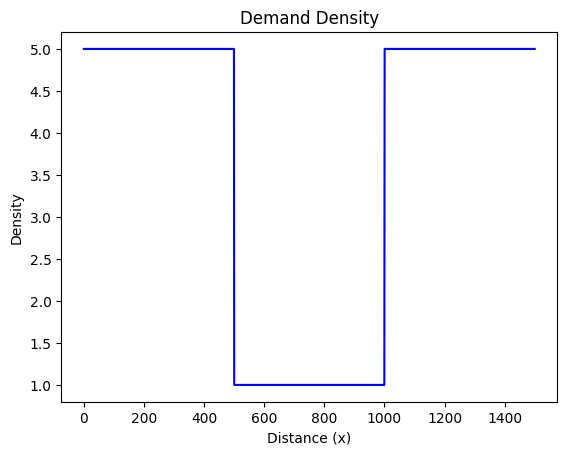

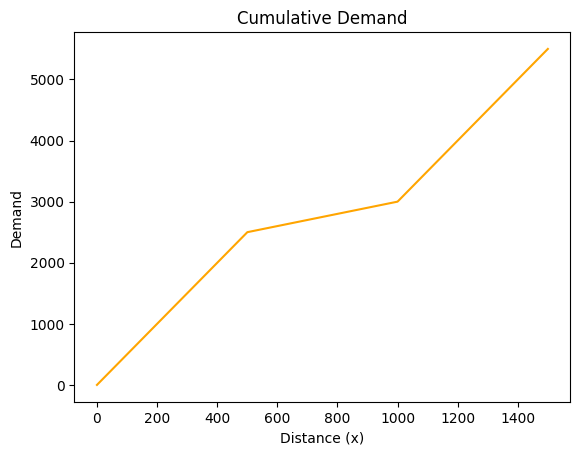

In [3]:
import matplotlib.pyplot as plt
import numpy as np
def demand_density(d): # w(x) or D'(x)
    if d <= 500:
        return 5
    elif d < 1000:
        return 1
    else:
        return 5
    
def cumulative_demand(d): # D(x)
    if d <= 500:
        return 5 * d
    elif d < 1000:
        return 5 * 500 + 1 * (d - 500)
    else:
        return 5 * 500 + 1 * (1000 - 500) + 5 * (d - 1000)

x = np.linspace(0, 1500, 1500)
y = [demand_density(d) for d in x]
plt.plot(x, y, label='Demand Density', color='blue')
plt.xlabel('Distance (x)')
plt.ylabel('Density')
plt.title('Demand Density')
plt.show()


x = np.linspace(0, 1500, 1500)
y = [cumulative_demand(d) for d in x]
plt.plot(x, y, label='Cumulative Demand', color='orange')
plt.xlabel('Distance (x)')
plt.ylabel('Demand')
plt.title('Cumulative Demand')
plt.show()

### a)
For 1 terminal we look for the point where $D(x) = D(1500)/2 \rightarrow x = 750$. We can verify this by seeing that $\int_0^{750} w(x) dx = \int_{750}^{1500} w(x) = 2750 = D(750)$. The access cost is calculated by evaluating $3\int_0^{1500} |x-750| \cdot w(x) dx$, which we can divide into parts: $\int_0^{750} (750-x) w(x) dx + \int_{750}^{1500} (x-750) w(x) dx$. Since $w(x)$ changes at $750$ and $1000$, we divide further: $\int_0^{500} (750-x) \cdot 5 dx + \int_{500}^{750} (750-x) \cdot 1 dx + \int_{750}^{1000} (x-750) \cdot 1 dx + \int_{1000}^{1500} (x-750) \cdot 5 dx = 3(1,250,000 + 31,250 + 31,250 + 1,250,000) = \textbf{7,687,500 \text{Mu/Tu}}$ with terminal at distance $\textbf{750}$. \
\
\
For 2 terminals we divide the space into two equal regions, which the 1 terminal problem already did for us. So our two regions are $[0, 750]$, and $[750, 1500]$. Again, since our demand density is symmetric, we can just calculate for $[0, 750]$ and reflect to the other region. We now look for the point where $D(x) = D(750)/2 \rightarrow x_1 = 255$. We can verify this by seeing that $\int_0^{255} w(x) dx = \int_{255}^{750} w(x) = 1275 = D(255)$. We also reflect the other terminal to $1500-255=1245=x_2$. The access cost is $2\cdot 3 \left( \int_0^{255} (255-x) \cdot 5 dx + \int_{255}^{500} (x-255) \cdot 5 dx + \int_{500}^{750} (x-255) \cdot 1 dx \right) = 2\cdot 3 (162,562.5 + 150,062.5 + 92,500) = \textbf{2,430,750 \text{Mu/Tu}}$ with terminals at distances $\textbf{255}$ and $\textbf{1245}$.
\
\
For 3 terminals, we look for where $x = D(1500)/3 \rightarrow x \approx 339$. So our regions are $[0, 339], [339, 1161], [1161, 1500]$. Since all of our regions have a symmetric $w(x)$, we can simply place the terminals in the center of each one. So our terminal locations are $x_1 = 169.5, x_2 = 750, x_3 = 1330.5$. The access cost is $3 \cdot \left( 2 \left( \int_0^{169.5} (169.5-x) \cdot 5 dx + \int_{169.5}^{339} (x-169.5) \cdot 5 dx \right) + \int_{339}^{500} (750-x) \cdot 5 dx + \int_{500}^{750} (750-x) \cdot 1 dx + \int_{750}^{1000} (x-750) \cdot 1 dx + \int_{1000}^{1161} (x-750) \cdot 5 dx \right) = 3 \left( 2(71,825.625 + 71,825.625) + 266,052.5 + 31,250 + 31,250 + 266,052.5 \right) = \textbf{2,645,722.5 \text{Mu/Tu}}$ with terminals at distances $\textbf{169.5}$, $\textbf{750}$, and $\textbf{1330.5}$.

### b)
We wish to locate terminals as close to the coordinates we listed above. For 1 terminal, $\textbf{707}$ is the closest, and the access cost is $\textbf{7,693,047 \text{Mu/Tu}}$ (calculated like above), a 0.072% increase. \
For 2 terminals, the best are $\textbf{258}$ and $\textbf{1289}$. This has an access cost of $\textbf{2,484,525 \text{Mu/Tu}}$, a 2.2% increase. \
For 3 terminals, the best are $\textbf{179}$, $\textbf{707}$, and $\textbf{1289}$, with an access cost of $\textbf{2,678,457 \text{Mu/Tu}}$, a 1.2% increase.

In [30]:
from sympy import symbols, integrate

def compute_integral(a, b, c):
    x = symbols('x')

    integral_value = 3*(
        integrate((a - x) * 5, (x, 0, a)) +
        integrate((x - a) * 5, (x, a, 339)) +
        integrate((b - x) * 5, (x, 339, 500)) +
        integrate((b - x) * 1, (x, 500, b)) +
        integrate((x - b) * 1, (x, b, 1000)) +
        integrate((x - b) * 5, (x, 1000, 1161)) +
        integrate((c - x) * 5, (x, 1161, c)) +
        integrate((x - c) * 5, (x, c, 1500))
    )

    return integral_value

result = compute_integral(179, 707, 1289)
print(f"The value of the integral is: {result}")

The value of the integral is: 2678457


### c)
Without location constraints: The optimal selection is 2 terminals, at 255 and 1245. The transportation cost is still $2,430,750$, plus the terminal cost of $2\cdot 120,000 = 340,000$, to give a total cost of $\textbf{2,770,750 Mu / Tu}$. \
With location constraints, the optimal selection is still 2 terminals, at 258 and 1289. The transportation cost is still $2,484,525$, plus the terminal cost of $2\cdot 120,000 = 340,000$, to give a total cost of $\textbf{2,824,525 Mu / Tu}$.

### d)
Using the cost estimate from the textbook:
$$\int_0^{d_{\max}} (c_s c'_d D'(d))^{1/2} dd$$
or
$$\text{Total Cost} \approx (c_s c'_d)^{1/2} \{ a\sqrt{D'_1} + (d_{\max}-a)\sqrt{D'_2}$$
We can plug in many values for this problem, extended in three segments (and $c_s$ is $c_T$ here): $a=500, b=1000, d_{\max}=1500, D(d_{\max})=5500, D'_1=5, D'_2=1, D'_3=1, c'_d=3$. We have
$$(3c_T)^{1/2} \{ 500\sqrt{5} + (1000-500)\sqrt{1} + (1500-1000)\sqrt{5} \}$$
$$(3c_T)^{1/2} (500(2\sqrt{5} + 1))$$
Then for any $c_T$ add $c_T \cdot n$ to the transportation costs $z$, and choose the lowest value. Plugging in $c_T=120,000$, we have Total cost: $\approx$

In [97]:
np.sqrt(3*120000) * (500*(2*np.sqrt(5) + 1)) + 120000*2

np.float64(1881640.786499874)

which is less than what we observed in c).

# Problem 6
We have two separate one-to-one distribution problems. Since the transportation cost is regardless of load size, we look at shipment size $v$ vs transportation cost/shipment. This is the graph that is somewhat like a step function, stepping at multiples of $v_{\max}$. The transportation cost is $\$1/\text{per mile} \cdot 300 \text{miles}$. The optimal shipment size is $$\min \{ Av+\frac{B}{v} \}, v\leq v_{\max}$$ for each $v$, with $A=0.15/D'_i, B=300$. From the textbook, the optimal dispatch frequency is $$H(t)=\sqrt{2c_f/(c_iD'(t))}$$
Plugging in, we have $$H(t)=\sqrt{2\cdot 300/(0.15D'(t))}$$
And the resulting cost $z$ is $$\approx \int_0^{t_{\max}} \left( \frac{c_f}{H(t)} + \frac{c_i H(t)}{2} D'(t) \right) dt$$